# Notebook 05 — Bowling Model
## IPL 2027 Franchise Squad Predictor

**Input:** `bowling_labelled.parquet`  
**Output:** `models/bowling_model.pkl`, `models/bowling_features.pkl`, `data/processed/bowling_scores.parquet`

**Same architecture as batting model — separate model because:**
- Bowling features are completely different (economy, wickets, dot%) 
- Positive rate is 32% vs batting's 22% — different class balance
- Feature importance will differ: death economy matters more than powerplay wickets for certain roles

---

## Step 0 — Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    average_precision_score, RocCurveDisplay
)

PROCESSED_DIR = r"E:\My ML Projects\2027 cricket squad prediction\data\processed"
MODELS_DIR    = r"E:\My ML Projects\2027 cricket squad prediction\models"

os.makedirs(MODELS_DIR, exist_ok=True)

bowling = pd.read_parquet(PROCESSED_DIR + 'processed_bowling_labelled.parquet')

print(f'Bowling labelled: {bowling.shape}')
print(f'Seasons: {sorted(bowling["season"].unique())}')
print(f'Target distribution:')
print(bowling[bowling['did_bowl']==1]['contributed_to_win'].value_counts())

FileNotFoundError: [Errno 2] No such file or directory: 'E:\\My ML Projects\\2027 cricket squad prediction\\data\\processedprocessed_bowling_labelled.parquet'

## Step 1 — Select Features

In [2]:
FEATURE_CANDIDATES = [
    # Recent form
    'form_economy',
    'form_wickets',
    'form_dot_pct',
    'form_runs_conceded',
    # Venue history
    'venue_avg_economy',
    'venue_avg_wickets',
    # Opponent matchup
    'vs_opp_avg_economy',
    'vs_opp_avg_wickets',
    # Reliability
    'consistency_wickets',
    'consistency_economy',
    # Phase-specific economy (death bowlers vs powerplay specialists)
    'phase_economy_Death',
    'phase_economy_Middle',
    'phase_economy_Powerplay',
    'phase_wickets_Death',
    'phase_wickets_Middle',
    'phase_wickets_Powerplay',
    # Recency
    'recency_weight',
]

FEATURES = [f for f in FEATURE_CANDIDATES if f in bowling.columns]
TARGET   = 'contributed_to_win'

print(f'Features selected : {len(FEATURES)}')
for f in FEATURES:
    null_pct = bowling[f].isnull().mean() * 100
    print(f'  {f:35s}  NaN: {null_pct:.1f}%')

Features selected : 17
  form_economy                         NaN: 11.9%
  form_wickets                         NaN: 11.9%
  form_dot_pct                         NaN: 11.9%
  form_runs_conceded                   NaN: 11.9%
  venue_avg_economy                    NaN: 41.2%
  venue_avg_wickets                    NaN: 41.2%
  vs_opp_avg_economy                   NaN: 28.8%
  vs_opp_avg_wickets                   NaN: 28.8%
  consistency_wickets                  NaN: 11.9%
  consistency_economy                  NaN: 11.9%
  phase_economy_Death                  NaN: 0.0%
  phase_economy_Middle                 NaN: 0.0%
  phase_economy_Powerplay              NaN: 0.0%
  phase_wickets_Death                  NaN: 0.0%
  phase_wickets_Middle                 NaN: 0.0%
  phase_wickets_Powerplay              NaN: 0.0%
  recency_weight                       NaN: 0.0%


## Step 2 — Time-Series Train / Test Split

In [3]:
TRAIN_SEASONS = list(range(2016, 2024))
TEST_SEASONS  = [2024, 2025]

bowled = bowling[bowling['did_bowl'] == 1].copy()

train = bowled[bowled['season'].isin(TRAIN_SEASONS)]
test  = bowled[bowled['season'].isin(TEST_SEASONS)]

X_train = train[FEATURES]
y_train = train[TARGET]
X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f'Train : {X_train.shape}  |  positive rate: {y_train.mean():.1%}')
print(f'Test  : {X_test.shape}   |  positive rate: {y_test.mean():.1%}')

Train : (5979, 17)  |  positive rate: 33.1%
Test  : (1725, 17)   |  positive rate: 28.7%


## Step 3 — Class Imbalance Weight

In [4]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = round(neg / pos, 2)

print(f'Train negatives : {neg:,}')
print(f'Train positives : {pos:,}')
print(f'scale_pos_weight: {scale_pos_weight}')

Train negatives : 3,999
Train positives : 1,980
scale_pos_weight: 2.02


## Step 4 — Train XGBoost Model

In [5]:
model = XGBClassifier(
    n_estimators          = 400,
    max_depth             = 5,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    scale_pos_weight      = scale_pos_weight,
    eval_metric           = 'logloss',
    early_stopping_rounds = 30,
    random_state          = 42,
    n_jobs                = -1,
)

model.fit(
    X_train, y_train,
    eval_set = [(X_test, y_test)],
    verbose  = 50,
)

print(f'\nBest iteration: {model.best_iteration}')

[0]	validation_0-logloss:0.67708
[50]	validation_0-logloss:0.42659
[100]	validation_0-logloss:0.39893
[150]	validation_0-logloss:0.38915
[200]	validation_0-logloss:0.38951
[201]	validation_0-logloss:0.38956

Best iteration: 171


## Step 5 — Evaluate on Test Set

In [6]:
y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)
avg_pr  = average_precision_score(y_test, y_pred_proba)

print('=' * 50)
print('BOWLING MODEL — TEST SET RESULTS')
print('=' * 50)
print(f'ROC-AUC              : {roc_auc:.4f}')
print(f'Avg Precision-Recall : {avg_pr:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['No Contribution', 'Contributed']))

BOWLING MODEL — TEST SET RESULTS
ROC-AUC              : 0.8808
Avg Precision-Recall : 0.6856

                 precision    recall  f1-score   support

No Contribution       0.89      0.84      0.86      1230
    Contributed       0.65      0.74      0.69       495

       accuracy                           0.81      1725
      macro avg       0.77      0.79      0.78      1725
   weighted avg       0.82      0.81      0.81      1725



## Step 6 — Visualise Results

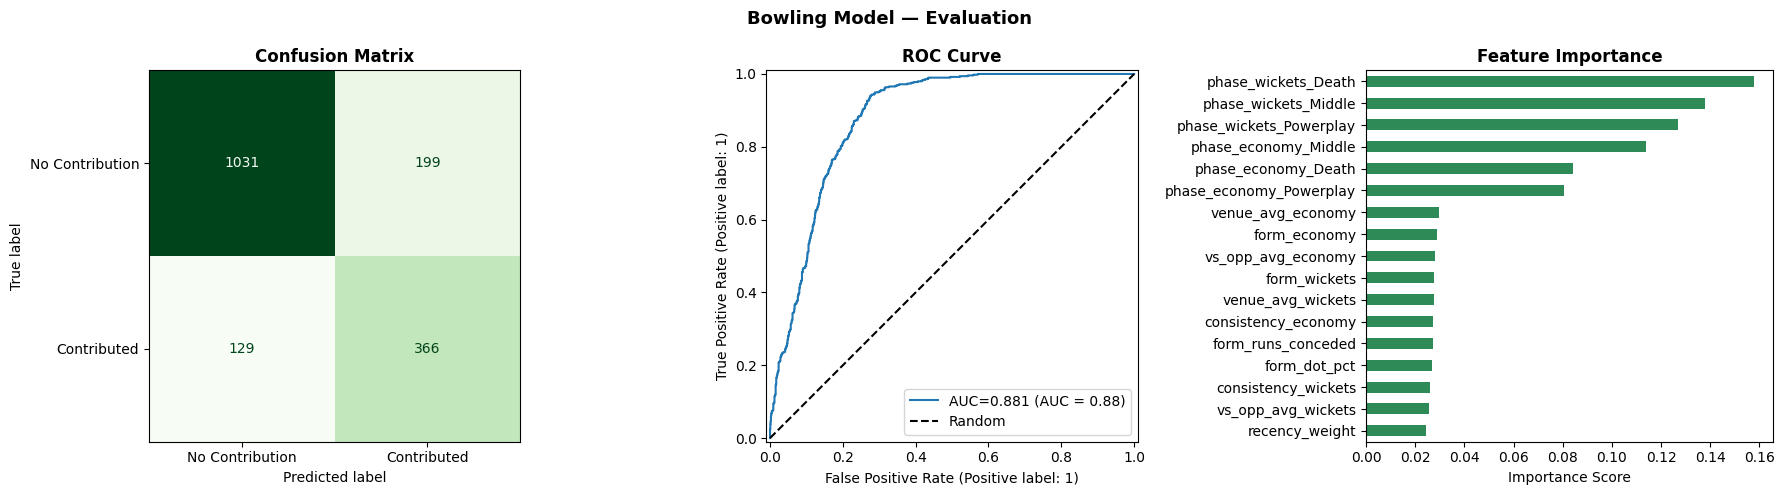

Plot saved.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Contribution', 'Contributed']).plot(
    ax=axes[0], colorbar=False, cmap='Greens'
)
axes[0].set_title('Confusion Matrix', fontweight='bold')

RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[1], name=f'AUC={roc_auc:.3f}')
axes[1].plot([0,1],[0,1],'k--', label='Random')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()

imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
imp.plot(kind='barh', ax=axes[2], color='seagreen')
axes[2].set_title('Feature Importance', fontweight='bold')
axes[2].set_xlabel('Importance Score')

plt.suptitle('Bowling Model — Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_DIR + 'bowling_model_evaluation.png', dpi=120)
plt.show()
print('Plot saved.')

## Step 7 — Score Every Player

In [8]:
latest_bowling = (
    bowled
    .sort_values(['player', 'season', 'match_id'])
    .groupby('player')
    .last()
    .reset_index()
)

X_latest = latest_bowling[FEATURES]
latest_bowling['bowl_win_prob'] = model.predict_proba(X_latest)[:, 1]

bowl_scores = latest_bowling[['player', 'bowl_win_prob', 'season']].sort_values(
    'bowl_win_prob', ascending=False
).reset_index(drop=True)

print('=== TOP 20 BOWLERS BY WIN CONTRIBUTION PROBABILITY ===')
print(bowl_scores.head(20).to_string(index=False))

=== TOP 20 BOWLERS BY WIN CONTRIBUTION PROBABILITY ===
           player  bowl_win_prob  season
       JD Unadkat       0.923451    2025
      Imran Tahir       0.907740    2021
         A Kamboj       0.874172    2025
        SM Boland       0.861930    2016
         J Little       0.842980    2024
          DR Sams       0.830453    2022
         UT Yadav       0.816010    2024
        KH Pandya       0.815657    2025
       GJ Maxwell       0.811721    2025
       KA Maharaj       0.807016    2024
          P Kumar       0.806645    2017
    Navdeep Saini       0.804576    2023
      Sachin Baby       0.803322    2016
      DG Nalkande       0.800270    2024
  Gurkeerat Singh       0.788723    2016
        PP Chawla       0.784921    2024
        AU Rashid       0.781341    2023
Mustafizur Rahman       0.779361    2025
    Kuldeep Yadav       0.761261    2025
      Harsh Dubey       0.752089    2025


## Step 8 — Build Combined Player Score Table

Players who appear in both batting and bowling scores are all-rounders.
Their combined score = average of batting + bowling probability.
This table feeds directly into Notebook 06 — the squad optimizer.

In [9]:
bat_scores = pd.read_parquet(PROCESSED_DIR + 'batting_scores.parquet')

# Tag each table
bat_scores = bat_scores.rename(columns={'season': 'bat_last_season'})
bowl_scores_save = bowl_scores.rename(columns={'season': 'bowl_last_season'})

# Merge on player
combined = bat_scores.merge(bowl_scores_save, on='player', how='outer')

# Classify role
combined['is_batter']     = combined['bat_win_prob'].notna().astype(int)
combined['is_bowler']     = combined['bowl_win_prob'].notna().astype(int)
combined['is_allrounder'] = ((combined['is_batter'] == 1) & (combined['is_bowler'] == 1)).astype(int)

# Combined score — all-rounders get average, specialists get their own score
combined['combined_score'] = combined[['bat_win_prob', 'bowl_win_prob']].mean(axis=1)

# Assign role label
def assign_role(row):
    if row['is_allrounder'] == 1:
        return 'AR'
    elif row['is_batter'] == 1:
        return 'BAT'
    else:
        return 'BOWL'

combined['role'] = combined.apply(assign_role, axis=1)

print('Role distribution in combined player table:')
print(combined['role'].value_counts())
print(f'\nTotal players: {len(combined)}')
print()
print('=== TOP 25 COMBINED PLAYERS ===')
print(
    combined[['player','role','bat_win_prob','bowl_win_prob','combined_score']]
    .sort_values('combined_score', ascending=False)
    .head(25)
    .round(3)
    .to_string(index=False)
)

Role distribution in combined player table:
role
AR      300
BAT     139
BOWL     47
Name: count, dtype: int64

Total players: 486

=== TOP 25 COMBINED PLAYERS ===
         player role  bat_win_prob  bowl_win_prob  combined_score
    Dhruv Jurel  BAT         0.911            NaN           0.911
     JG Bethell  BAT         0.895            NaN           0.895
     UT Khawaja  BAT         0.886            NaN           0.886
     RR Rossouw  BAT         0.878            NaN           0.878
      SM Boland BOWL           NaN          0.862           0.862
    Urvil Patel  BAT         0.851            NaN           0.851
B Sai Sudharsan  BAT         0.849            NaN           0.849
       J Little BOWL           NaN          0.843           0.843
      JM Sharma  BAT         0.782            NaN           0.782
      H Klaasen  BAT         0.771            NaN           0.771
   Sameer Rizvi  BAT         0.771            NaN           0.771
    Harsh Dubey BOWL           NaN          

## Step 9 — Save Everything

In [10]:
joblib.dump(model,    MODELS_DIR + 'bowling_model.pkl')
joblib.dump(FEATURES, MODELS_DIR + 'bowling_features.pkl')

bowl_scores.to_parquet(PROCESSED_DIR + 'bowling_scores.parquet', index=False)
combined.to_parquet(PROCESSED_DIR + 'combined_player_scores.parquet', index=False)

print('Saved:')
print('  models/bowling_model.pkl')
print('  models/bowling_features.pkl')
print('  data/processed/bowling_scores.parquet')
print('  data/processed/combined_player_scores.parquet')

Saved:
  models/bowling_model.pkl
  models/bowling_features.pkl
  data/processed/bowling_scores.parquet
  data/processed/combined_player_scores.parquet


## Step 10 — Validation Checks

In [11]:
checks = [
    ('bowling_model.pkl saved',           os.path.exists(MODELS_DIR + 'bowling_model.pkl')),
    ('bowling_features.pkl saved',        os.path.exists(MODELS_DIR + 'bowling_features.pkl')),
    ('bowling_scores.parquet saved',      os.path.exists(PROCESSED_DIR + 'bowling_scores.parquet')),
    ('combined_player_scores saved',      os.path.exists(PROCESSED_DIR + 'combined_player_scores.parquet')),
    ('ROC-AUC above 0.55',                roc_auc > 0.55),
    ('Bowl scores between 0 and 1',       bowl_scores['bowl_win_prob'].between(0,1).all()),
    ('Combined table has role column',    'role' in combined.columns),
    ('All-rounders identified',           (combined['role'] == 'AR').sum() > 0),
    ('More than 50 players in combined',  len(combined) > 50),
]

all_pass = True
for name, result in checks:
    icon = '✓' if result else '✗  FAIL'
    print(f'{icon}  {name}')
    if not result:
        all_pass = False

print(f'\n  Bowling ROC-AUC : {roc_auc:.4f}')
print(f'  Total players   : {len(combined)}')
print(f'  All-rounders    : {(combined["role"] == "AR").sum()}')
print()
if all_pass:
    print('All checks passed. Proceed to Notebook 06 — Squad Optimizer.')
else:
    print('Fix failing checks before proceeding.')

✓  bowling_model.pkl saved
✓  bowling_features.pkl saved
✓  bowling_scores.parquet saved
✓  combined_player_scores saved
✓  ROC-AUC above 0.55
✓  Bowl scores between 0 and 1
✓  Combined table has role column
✓  All-rounders identified
✓  More than 50 players in combined

  Bowling ROC-AUC : 0.8808
  Total players   : 486
  All-rounders    : 300

All checks passed. Proceed to Notebook 06 — Squad Optimizer.
